## Assignment Computer Vision About Face Detection



1. Cropping **the dog's face**, save it into another variable to use as a template.
2. Perform template matching using 6 methods (as in the video)
3. Compare the results, create a chart to compare the 6 methods `x-axis`: list method, `y-axis`: how far the original image point is from the template matching result.

---

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
full = cv2.imread('dog_backpack.jpg')
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)

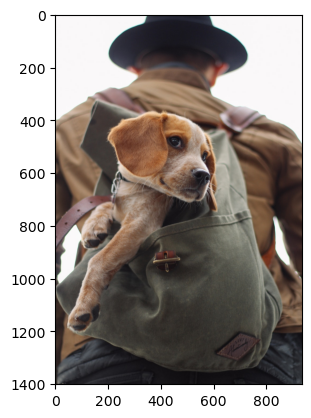

In [5]:
plt.imshow(full)

In [26]:
face = cv2.imread('dog_backpack_face.jpg')
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

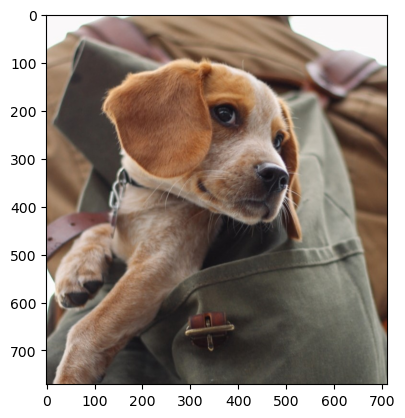

In [27]:
plt.imshow(face)

# Template Matching Methods

Make sure to watch the video for an explanation of the different methods!

---

In [28]:
sum([1,2,3])
mystring = 'sum'

In [29]:
eval(mystring)

<function sum(iterable, /, start=0)>

In [30]:
myfunc = eval(mystring)
myfunc([1,2,3])

6

In [31]:
height, width,channels = face.shape

In [32]:
width

711

In [33]:
height

771

In [35]:
# The Full Image to Search
full = cv2.imread('dog_backpack.jpg')
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)


# The Template to Match
face= cv2.imread('dog_backpack_face.jpg')
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)


# All the 6 methods for comparison in a list
# Note how we are using strings, later on we'll use the eval() function to convert to function
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR','cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

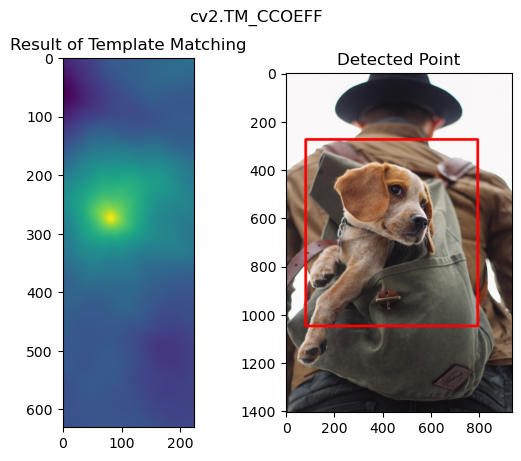

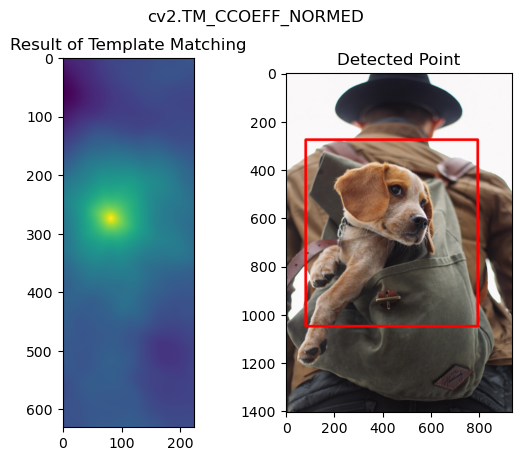

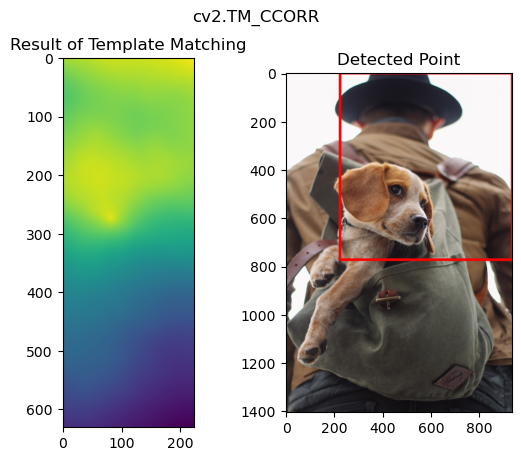

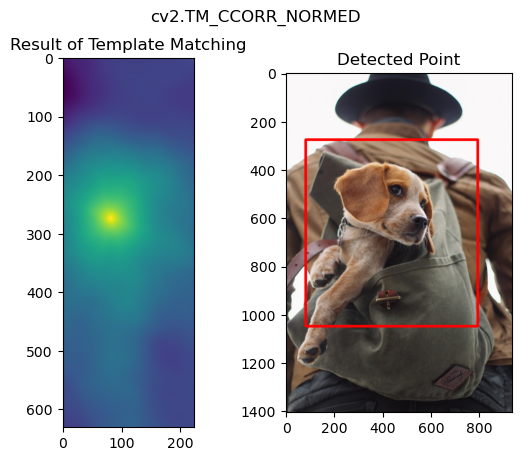

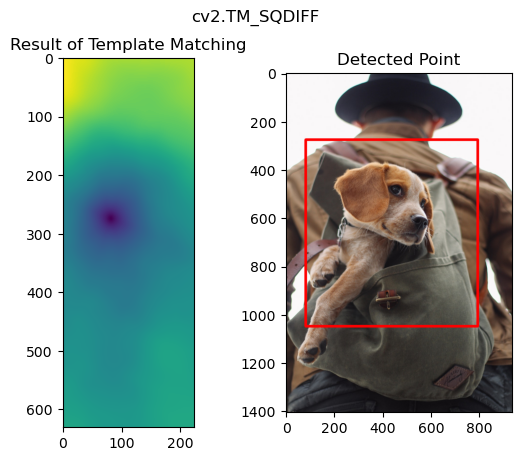

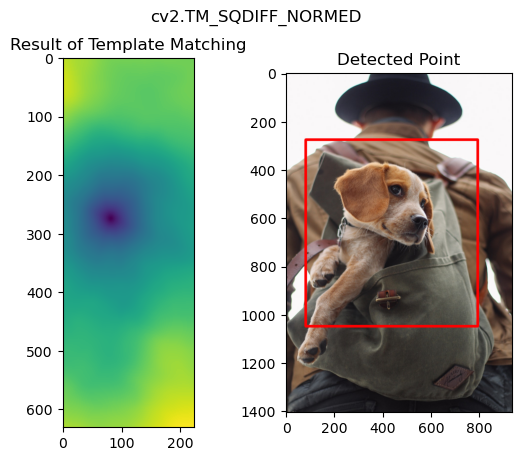

In [36]:
for m in methods:
    
    # Create a copy of the image
    full_copy = full.copy()
    
    # Get the actual function instead of the string
    method = eval(m)

    # Apply template Matching with the method
    res = cv2.matchTemplate(full_copy,face,method)
    
    # Grab the Max and Min values, plus their locations
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    
    # Set up drawing of Rectangle
    
    # If the method is TM_SQDIFF or TM_SQDIFF_NORMED, take minimum
    # Notice the coloring on the last 2 left hand side images.
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc    
    else:
        top_left = max_loc
        
    # Assign the Bottom Right of the rectangle
    bottom_right = (top_left[0] + width, top_left[1] + height)

    # Draw the Red Rectangle
    cv2.rectangle(full_copy,top_left, bottom_right, 255, 10)

    # Plot the Images
    plt.subplot(121)
    plt.imshow(res)
    plt.title('Result of Template Matching')
    
    plt.subplot(122)
    plt.imshow(full_copy)
    plt.title('Detected Point')
    plt.suptitle(m)
    
    
    plt.show()
    print('\n')
    print('\n')
    

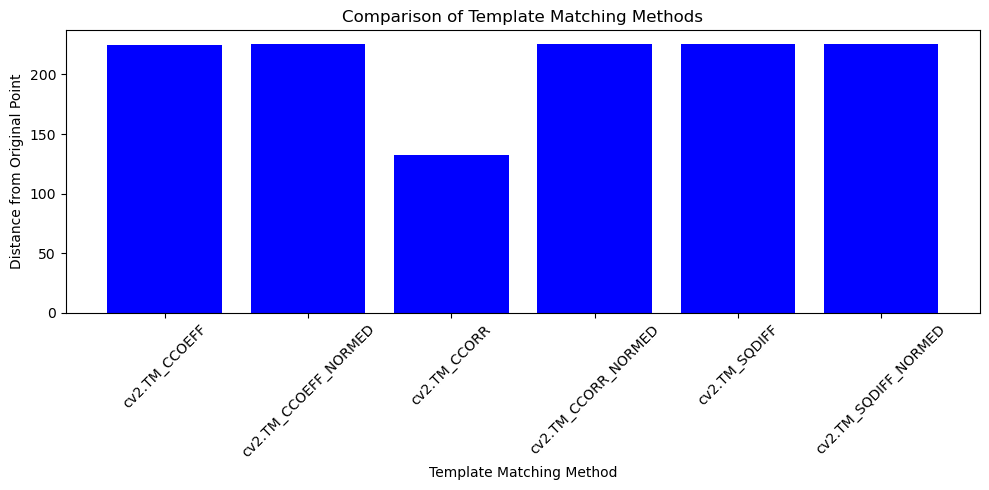

In [ ]:
full = cv2.imread('dog_backpack.jpg')
template = cv2.imread('dog_backpack_face.jpg')  # Assuming you have cropped the dog's face and saved it as 'dog_face.jpg'
full_gray = cv2.cvtColor(full, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

# Get the dimensions of the template
h, w = template_gray.shape

# List of methods
methods = [
    'cv2.TM_CCOEFF',
    'cv2.TM_CCOEFF_NORMED',
    'cv2.TM_CCORR',
    'cv2.TM_CCORR_NORMED',
    'cv2.TM_SQDIFF',
    'cv2.TM_SQDIFF_NORMED'
]

distances = []

# Loop over each method
for method in methods:
    method_eval = eval(method)  # Evaluate the method name to get the actual method
    result = cv2.matchTemplate(full_gray, template_gray, method_eval)
    
    # Get the best match location
    if method in ['cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']:
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
        match_loc = min_loc
    else:
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
        match_loc = max_loc
    
    # Calculate the distance from the original point (assumed to be (x, y))
    original_point = (x, y)  # Replace with the actual coordinates of the original point
    distance = np.sqrt((match_loc[0] - original_point[0])**2 + (match_loc[1] - original_point[1])**2)
    distances.append(distance)

# Create the chart
plt.figure(figsize=(10, 5))
plt.bar(methods, distances, color='blue')
plt.xlabel('Template Matching Method')
plt.ylabel('Distance from Original Point')
plt.title('Comparison of Template Matching Methods')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()